# (11) Feeder: MNIST+rotate


**Motivation**:  <br>

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Part 1) get MNIST rotate feeder

### Load MNIST

In [3]:
trn, vld, _ = make_dataset('MNIST', device)

### Make rotate feeder

In [4]:
from main.datafeeder import RotateFeeder


feeder_kws = dict(
    theta_0=None,
    max_delta_theta=4.0,
    sample_uniform=True,
    batch_size=100,
    max_epochs=50,
    anneal_portion=0.0,
    device=device,
)

# use for training
feeder_trn = RotateFeeder(
    x=trn[0],
    y=trn[1],
    shuffle=True,
    drop_last=True,
    **feeder_kws,
)

# use for validation
feeder_vld = RotateFeeder(
    x=vld[0],
    y=vld[1],
    shuffle=False,
    drop_last=False,
    **feeder_kws,
)
# calling apply_anneal() will set current_delta_theta
# before using feeder_vld, always call this:
_ = feeder_vld.apply_anneal(-1)

In [5]:
print(feeder_trn)

RotateFeeder(batch_size=100, iters_per_epoch=600, max_epochs=50, device=cuda:1, sample_uniform=True, 
max_delta_theta=4.0, theta_0=None)

### Training loop

Here's how a training loop looks like

In [6]:
t_train = 32

data_to_plot = []

for epoch in range(feeder_trn.max_epochs):
    feeder_trn.set_epoch(epoch)
    
    # loop over batches of data
    for i in range(len(feeder_trn)):
        gstep = epoch * len(feeder_trn) + i
        feeder_trn.set_rng(gstep)
        feeder_trn.apply_anneal(gstep)
        # sample a fresh batch of data
        _ = feeder_trn.get_batch_data(i)

        # inference trajectory
        for t in range(t_train):
            # stream data
            x_batch, *_ = feeder_trn.step()
            # output = self.model(x_batch)
            
            # save data here to plot
            data_to_plot.append(x_batch)
        break
    break
    
data_to_plot = torch.stack(data_to_plot, dim=1)
data_to_plot = tonp(data_to_plot)
data_to_plot.shape

(100, 32, 1, 28, 28)

### Plot some samples across time

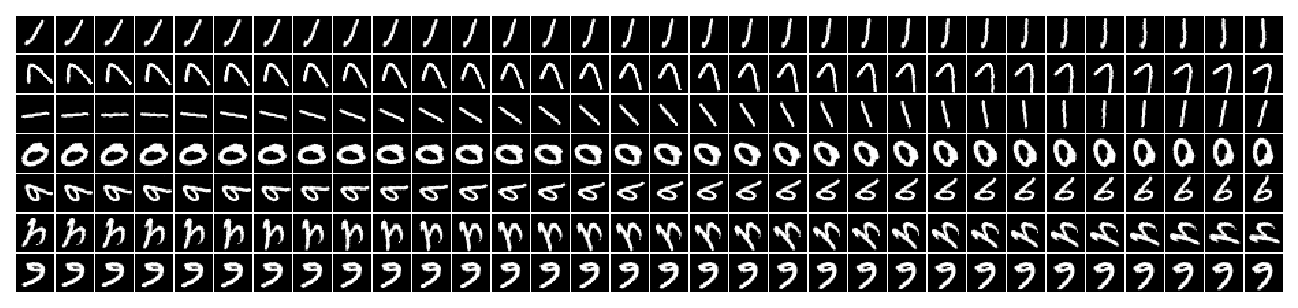

In [7]:
num = 7
_ = plot_weights(flatten_np(data_to_plot[:num], end_dim=1), nrows=7, method='none')

### Make movie

In [8]:
from utils.animation import show_movie

show_movie(data_to_plot[1].squeeze())

## Part 2) Get MNIST variance map

This will be used to mask CelebA data

### Make MNIST feeder

In [9]:
trn, _, _ = make_dataset('MNIST', device)

In [10]:
from main.datafeeder import RotateFeeder


feeder_kws = dict(
    theta_0=None,
    max_delta_theta=4.0,
    sample_uniform=True,
    batch_size=5_000,  # large batch size
    max_epochs=50,
    anneal_portion=0.0,
    device=device,
)

feeder_mnist = RotateFeeder(
    x=trn[0],
    y=trn[1],
    shuffle=False,
    drop_last=True,
    **feeder_kws,
)

In [11]:
t_total = 300
n_data_batches = 2

feeder_mnist.set_epoch(0)
feeder_mnist.apply_anneal(-1)

# loop over data
looper_data = tqdm(
    range(n_data_batches),
    ncols=70,
)
data = []
for i in looper_data:
    feeder_mnist.set_rng(i)
    _ = feeder_mnist.get_batch_data(i)
    for t in range(t_total):
        looper_data.set_description(
            f"batch #{i+1}, (t = {t+1})")
        x, *_ = feeder_mnist.step()
        data.append(x)
sigma = torch.std(
    torch.cat(data),
    unbiased=False,
    keepdim=True,
    dim=0,
)

del data, x
torch.cuda.empty_cache()
torch.cuda.synchronize()

batch #2, (t = 300): 100%|██████████████| 2/2 [00:01<00:00,  1.28it/s]


In [12]:
var_mnist = tonp(torch.square(sigma.squeeze()))
mask_mnist = var_mnist / np.max(var_mnist)

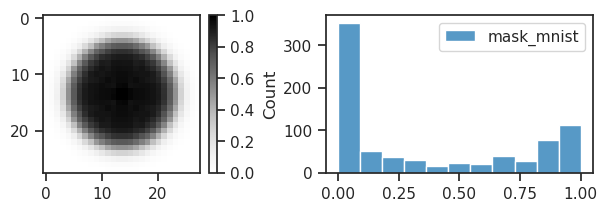

In [13]:
fig, axes = create_figure(1, 2, (6, 2), width_ratios=[1, 1.5])

im = axes[0].imshow(mask_mnist, cmap='Greys')
plt.colorbar(im, ax=axes[0])

sns.histplot(mask_mnist.ravel(), label='mask_mnist', ax=axes[1])
axes[1].legend()

plt.show()

### Upsample mask

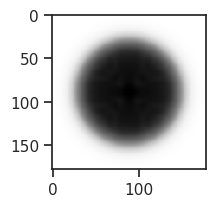

In [14]:
new_stim_dim = 178  # CelebA dim

mask_mnist_up = F_vis.resize(
    torch.tensor(mask_mnist).unsqueeze(0),
    size=[new_stim_dim, new_stim_dim],
    interpolation=F_vis.InterpolationMode.BICUBIC,
    antialias=True,
).squeeze()

mask_mnist_up = tonp(mask_mnist_up)
mask_mnist_up = mask_mnist_up / np.max(mask_mnist_up)

imshow(mask_mnist_up, cmap='Grays', vmin=0, vmax=1);

## Part 3) Prep CelebA feeder

### Load CelebA

In [15]:
%%time

_, vld, _ = make_dataset('CelebA', device='cpu', skip_trn=True)

CPU times: user 8.58 s, sys: 1min 7s, total: 1min 15s
Wall time: 11.6 s


### convert to grayscale

In [16]:
n_samples = 360  # dataset too big, get a subsample

x = vld[0][:n_samples]
x_shift_scaled = (x + 1.0) / 2.0

x_shift_scaled.shape

torch.Size([360, 3, 178, 178])

In [17]:
weights = torch.tensor(
    [0.299, 0.587, 0.114],
    device=x_shift_scaled.device,
    dtype=x_shift_scaled.dtype,
).view(1, 3, 1, 1)

# rescale to [0, 1], grayscale
# w/ BT.601 luma, keep channel dim
x_gray = torch.sum(
    x_shift_scaled * weights,
    dim=1, keepdim=True,
)

x_gray = x_gray.clamp(0, 1)
x_gray.shape

torch.Size([360, 1, 178, 178])

### apply MNIST variance mask

In [18]:
mask_tensor = torch.tensor(
    data=mask_mnist_up,
    device=x_gray.device,
    dtype=x_gray.dtype,
).unsqueeze(0).unsqueeze(0)

In [19]:
x_gray_masked = x_gray * mask_tensor
x_gray_masked.shape

torch.Size([360, 1, 178, 178])

### plot hist

- MNIST, vs.
- masked, grayscaled CelebA

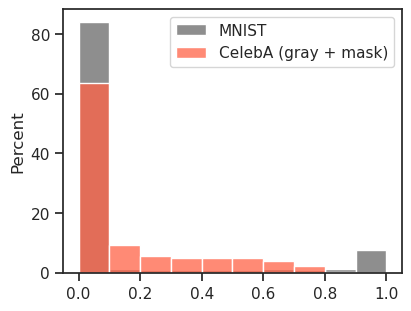

In [20]:
fig, ax = create_figure(1, 1, (4, 3))
kws = dict(bins=np.linspace(0, 1, 11), stat='percent', ax=ax)
sns.histplot(tonp(feeder_mnist.x[:10].ravel()), color='dimgrey', label='MNIST', **kws)
sns.histplot(tonp(x_gray_masked[:10].ravel()), color='tomato', label='CelebA (gray + mask)', **kws)
add_legend(ax)
plt.show()

### plot faces

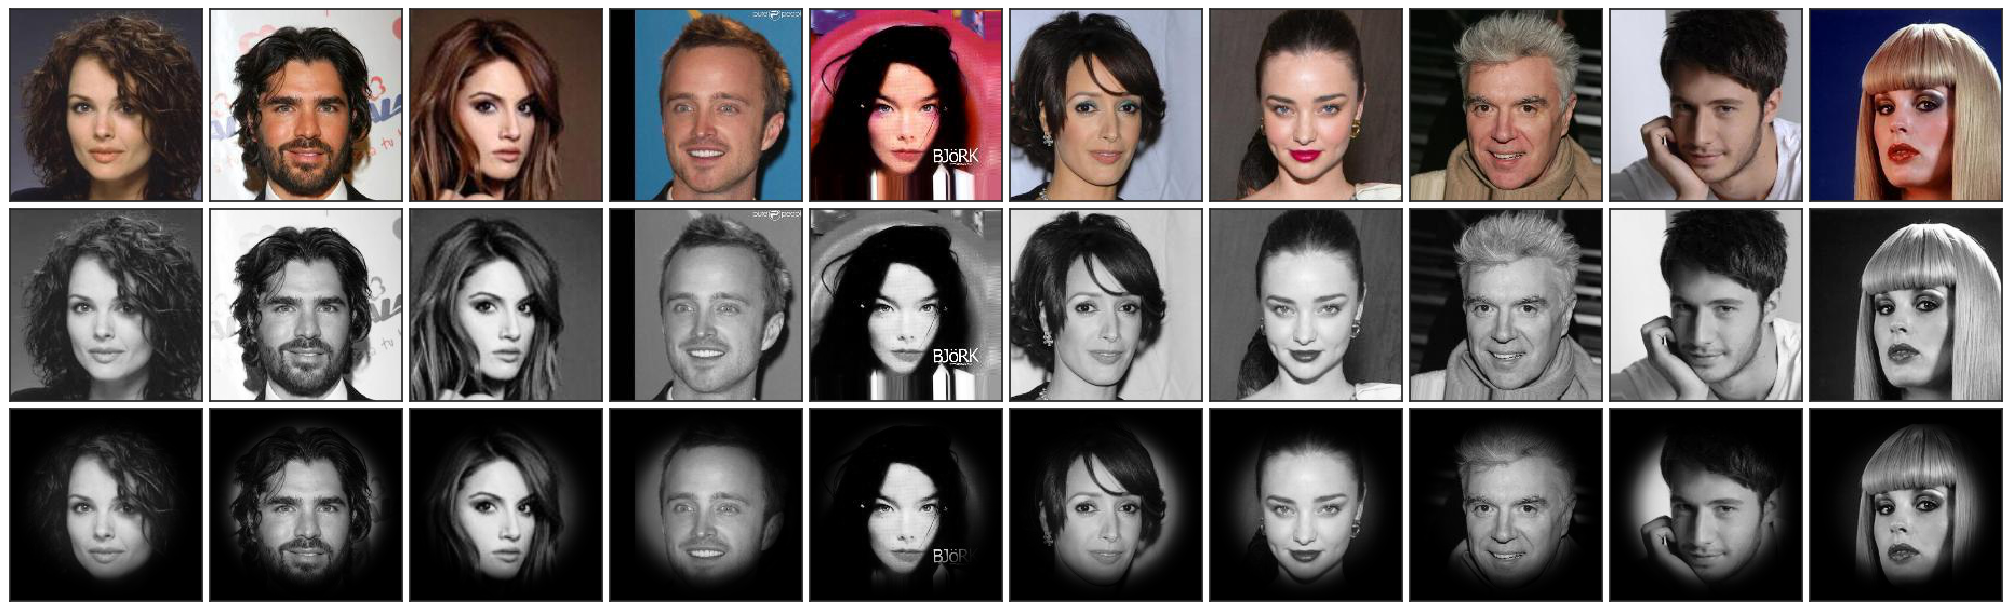

In [21]:
nrows, ncols = 3, 10
fig, axes = create_figure(nrows, ncols, (2 * ncols, 2 * nrows), 'all', 'all')

for i in range(ncols):
    x2p = np.transpose(tonp(x_shift_scaled[i]), (1, 2, 0))
    axes[0, i].imshow(x2p)
    
    x2p = tonp(x_gray[i].squeeze())
    axes[1, i].imshow(x2p, cmap='Greys_r', vmin=0, vmax=1)
    
    x2p = tonp(x_gray_masked[i].squeeze())
    axes[2, i].imshow(x2p, cmap='Greys_r', vmin=0, vmax=1)

remove_ticks(axes, False)
plt.show()

### make CelebA feeder

In [22]:
mnist_stim_dim = 28
new_stim_dim = x_gray_masked.shape[-1]
new_delta_theta = (  # logic: to preserve comparable translational velocity 
    feeder_mnist.max_delta_theta *
    mnist_stim_dim / new_stim_dim
)
new_delta_theta

0.6292134831460674

In [23]:
feeder_celeba = feeder_mnist.fork(
    reinit=True,
    x=x_gray_masked,
    y=vld[1][:n_samples],
    shuffle=False,
    drop_last=False,
    batch_size=60,
    max_delta_theta=new_delta_theta,
)
d_thetas = feeder_celeba.apply_anneal(-1)

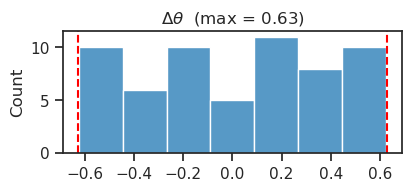

In [24]:
fig, ax = create_figure(1, 1, (4, 1.8))
sns.histplot(tonp(d_thetas), ax=ax)
ax.axvline(-feeder_celeba.max_delta_theta, color='r', ls='--')
ax.axvline(feeder_celeba.max_delta_theta, color='r', ls='--')
ax.set_title(r"$\Delta \theta$" + f"  (max = {feeder_celeba.max_delta_theta:0.2f})")
plt.show()